In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import seaborn as sns
import matplotlib.pyplot as plt
from semopy import Model


df2 = pd.read_excel('C:\\Users\\Girisha Jain\\MainData.xlsx')


In [2]:
df = df2.iloc[:,1:32]

In [3]:
df.columns

Index(['BB_ToU', 'BB_AcademicReputation', 'BB_ProgramOffered',
       'BB_CourseCurriculum', 'BB_CulturalExperience',
       'BB_Facilities_resources', 'BB_SafetyCampus', 'BB_DressCode',
       'BB_Infrastructure', 'BB_FacultyProfile', 'BB_Discipline',
       'BB_CareerOpportunities', 'BB_HS', 'SN_Family', 'SN_Friends',
       'SN_Seniors', 'SN_RelativesNeighbors', 'SN_Teachers',
       'SN_SameBehaviour', 'Selfesteem', 'PB_ScholarshipAvailability',
       'PB_UniversityTeamGuidance', 'PB_LanguageSpoken',
       'PB_AccomodationCostofLiving', 'PB_SafetyinCampus',
       'PB_UniversitylocatedCity', 'PB_CourseFee', 'PB_Ranking',
       'PB_ReputationBrand', 'PB_AvailabilityofCourse', 'PB_NearbytoHome'],
      dtype='object')

In [7]:
# Define the split ratio (e.g., 50% for EFA, 50% for CFA)

efa_size = 0.5  # Adjust this ratio as needed

# Perform the split

efa_data, cfa_data = train_test_split(df1, test_size=efa_size, random_state=42)

In [5]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")
    # Define the value mapping

BB_ToU: ['Very Important' 'Important' 'Very Unimportant' 'Unimportant' 'Neutral']
BB_AcademicReputation: ['Very Important' 'Very Unimportant' 'Important' 'Neutral' 'Unimportant']
BB_ProgramOffered: ['Very Important' 'Very Unimportant' 'Important' 'Neutral' 'Unimportant']
BB_CourseCurriculum: ['Very Important' 'Very Unimportant' 'Important' 'Neutral' 'Unimportant']
BB_CulturalExperience: ['Very Important' 'Very Unimportant' 'Neutral' 'Unimportant' 'Important']
BB_Facilities_resources: ['Very Important' 'Very Unimportant' 'Neutral' 'Important' 'Unimportant']
BB_SafetyCampus: ['Very Important' 'Very Unimportant' 'Important' 'Neutral' 'Unimportant']
BB_DressCode: ['Important' 'Very Unimportant' 'Very Important' 'Unimportant' 'Neutral']
BB_Infrastructure: ['Important' 'Very Unimportant' 'Neutral' 'Unimportant' 'Very Important']
BB_FacultyProfile: ['Very Important' 'Very Unimportant' 'Neutral' 'Important' 'Unimportant']
BB_Discipline: ['Very Important' 'Very Unimportant' 'Unimportant' 'Impor

In [6]:
response_map = {
    'Very Unimportant': 1,
    'Unimportant': 2,
    'Neutral': 3,
    'Important': 4,
    'Very Important': 5,
    'No Influence at all': 1,
    'Very little Influence': 2,
    'Moderate Influence':3,
    'Significant Influence':4,
    'Extreme Influence':5
}

df1 = df.replace(response_map)

In [8]:
df1.corr()

,BB_ToU,BB_AcademicReputation,BB_ProgramOffered,BB_CourseCurriculum,BB_CulturalExperience,BB_Facilities_resources,BB_SafetyCampus,BB_DressCode,BB_Infrastructure,BB_FacultyProfile,...,PB_UniversityTeamGuidance,PB_LanguageSpoken,PB_AccomodationCostofLiving,PB_SafetyinCampus,PB_UniversitylocatedCity,PB_CourseFee,PB_Ranking,PB_ReputationBrand,PB_AvailabilityofCourse,PB_NearbytoHome
BB_ToU,1.000000,0.808430,0.767440,0.801474,0.755852,0.777151,0.785640,0.548722,0.733893,0.757245,...,0.477371,0.491154,0.537641,0.566276,0.505166,0.521387,0.554311,0.526783,0.580378,0.335688
BB_AcademicReputation,0.808430,1.000000,0.850869,0.880008,0.806531,0.850258,0.853251,0.562866,0.793268,0.838458,...,0.510257,0.515244,0.552026,0.606362,0.521575,0.548916,0.603859,0.598363,0.623937,0.357447
BB_ProgramOffered,0.767440,0.850869,1.000000,0.889815,0.814980,0.816545,0.822216,0.568594,0.768872,0.803036,...,0.468865,0.488745,0.509386,0.579512,0.498818,0.536767,0.553188,0.558928,0.607183,0.354339
BB_CourseCurriculum,0.801474,0.880008,0.889815,1.000000,0.842714,0.867556,0.872772,0.586973,0.795840,0.866611,...,0.503446,0.513630,0.532101,0.621082,0.534065,0.549659,0.579467,0.567689,0.630552,0.377507
BB_CulturalExperience,0.755852,0.806531,0.814980,0.842714,1.000000,0.849269,0.827014,0.611515,0.779942,0.793925,...,0.491976,0.477663,0.498586,0.558212,0.492728,0.518191,0.560886,0.556320,0.574479,0.364961
BB_Facilities_resources,0.777151,0.850258,0.816545,0.867556,0.849269,1.000000,0.891718,0.579345,0.807213,0.856148,...,0.520649,0.505216,0.546887,0.607059,0.514463,0.539508,0.578737,0.575796,0.623479,0.363134
BB_SafetyCampus,0.785640,0.853251,0.822216,0.872772,0.827014,0.891718,1.000000,0.587452,0.826139,0.870131,...,0.516845,0.506093,0.539870,0.654798,0.524575,0.566752,0.594873,0.599317,0.630139,0.358361
BB_DressCode,0.548722,0.562866,0.568594,0.586973,0.611515,0.579345,0.587452,1.000000,0.638518,0.586201,...,0.384091,0.369579,0.385380,0.393097,0.377722,0.388404,0.383240,0.390881,0.357980,0.293111
BB_Infrastructure,0.733893,0.793268,0.768872,0.795840,0.779942,0.807213,0.826139,0.638518,1.000000,0.819286,...,0.484909,0.491358,0.516092,0.564524,0.494034,0.520551,0.562196,0.565363,0.571236,0.366160
BB_FacultyProfile,0.757245,0.838458,0.803036,0.866611,0.793925,0.856148,0.870131,0.586201,0.819286,1.000000,...,0.494203,0.496147,0.534595,0.605857,0.514207,0.561317,0.579706,0.576344,0.607152,0.367552


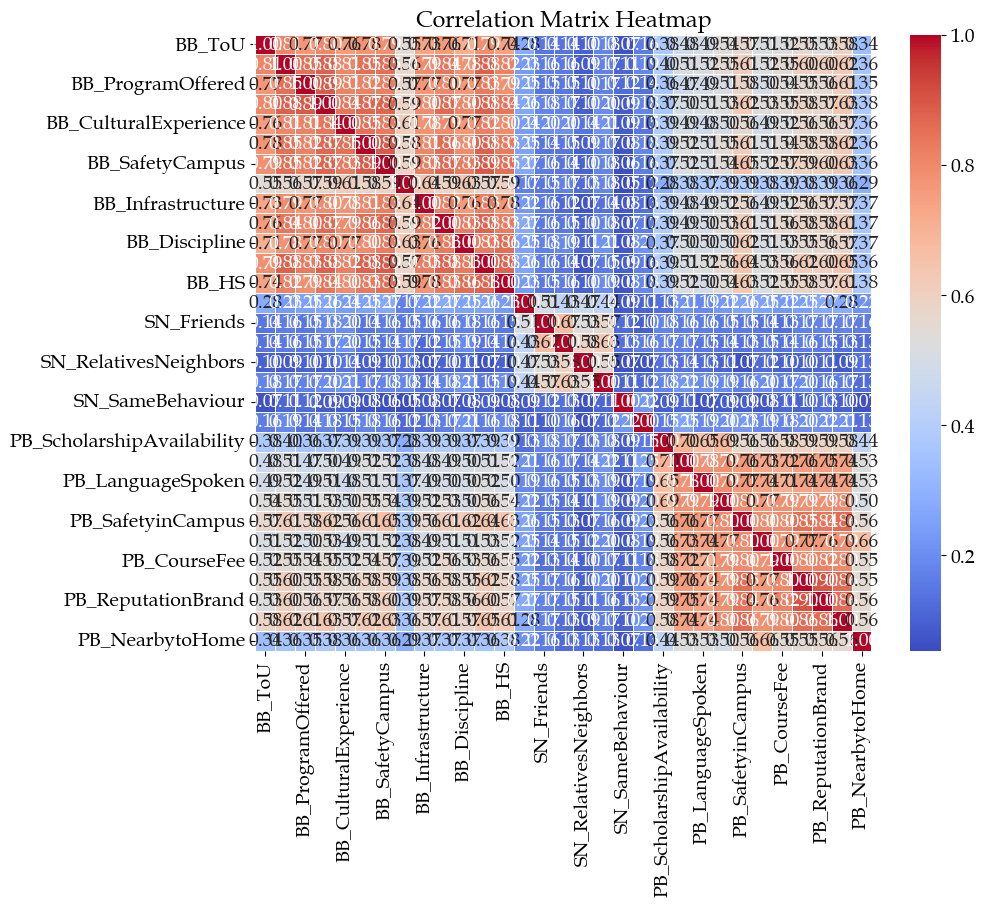

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df1.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))  # Adjust size as needed
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)

plt.title("Correlation Matrix Heatmap")
plt.show()


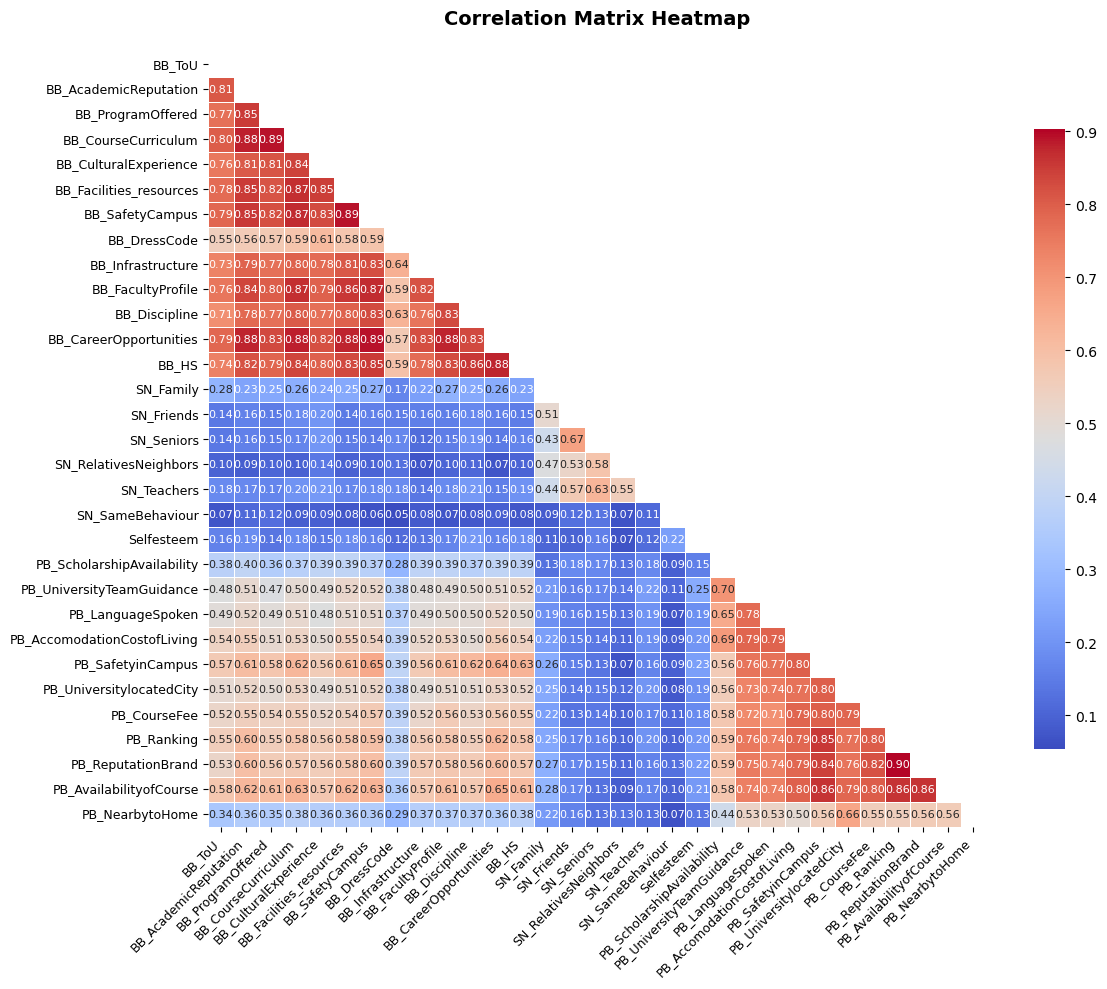

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute correlation matrix
corr_matrix = df1.corr()

# Mask upper triangle to avoid duplicate values
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(12, 10))  
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8}, 
    annot_kws={"size":8}  # control annotation font size
)

plt.title("Correlation Matrix Heatmap", fontsize=14, weight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
# KMO Test
kmo_all, kmo_model = calculate_kmo(df1)
print("KMO Model Value:", round(kmo_model, 3))  # should be > 0.6

KMO Model Value: 0.971


C:\Users\Girisha Jain\anaconda3\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [9]:
chi_square_value, p_value = calculate_bartlett_sphericity(df1)
print("Bartlett’s Test p-value:", p_value)  # should be < 0.05

Bartlett’s Test p-value: 0.0


In [10]:
# Initialize and fit Factor Analyzer
fa = FactorAnalyzer(n_factors=5, rotation='varimax')  # Adjust n_factors as needed
fa.fit(efa_data)

FactorAnalyzer(n_factors=5, rotation='varimax', rotation_kwargs={})

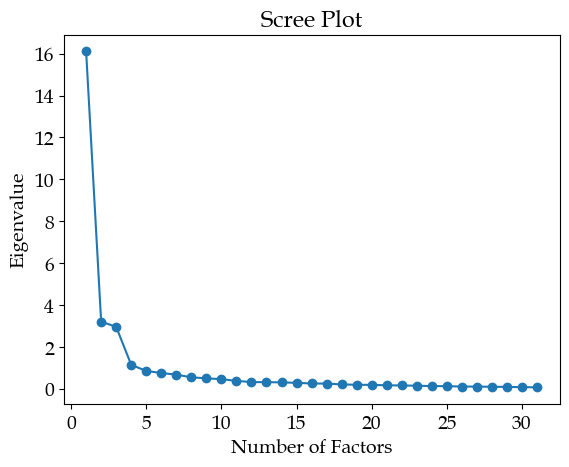

                                    0         1         2         3         4
BB_ToU                       0.773386  0.295223  0.109628  0.020060  0.024780
BB_AcademicReputation        0.850394  0.319136  0.096663  0.086649 -0.017332
BB_ProgramOffered            0.823873  0.301425  0.105340  0.093536 -0.041803
BB_CourseCurriculum          0.884260  0.306999  0.096461  0.059357 -0.052570
BB_CulturalExperience        0.832955  0.279344  0.119408  0.005397  0.032233
BB_Facilities_resources      0.873783  0.286092  0.066131  0.029450 -0.028577
BB_SafetyCampus              0.879919  0.308798  0.107925  0.016365 -0.047840
BB_DressCode                 0.628555  0.218529  0.136465  0.003337  0.097301
BB_Infrastructure            0.809015  0.337569  0.082264  0.039249  0.070819
BB_FacultyProfile            0.868575  0.292257  0.100678  0.034489  0.029845
BB_Discipline                0.804446  0.316329  0.135617  0.025720 -0.008124
BB_CareerOpportunities       0.880670  0.315258  0.059092  0.054

In [11]:
# Scree Plot for Eigenvalues
ev, _ = fa.get_eigenvalues()
plt.plot(range(1, len(ev)+1), ev, marker="o")
plt.xlabel("Number of Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

# Display factor loadings
loadings = pd.DataFrame(fa.loadings_, index=efa_data.columns)
print(loadings)

In [12]:
# Initialize and fit Factor Analyzer
fa = FactorAnalyzer(n_factors=4, rotation='varimax')  # Adjust n_factors as needed
fa.fit(efa_data)

FactorAnalyzer(n_factors=4, rotation='varimax', rotation_kwargs={})

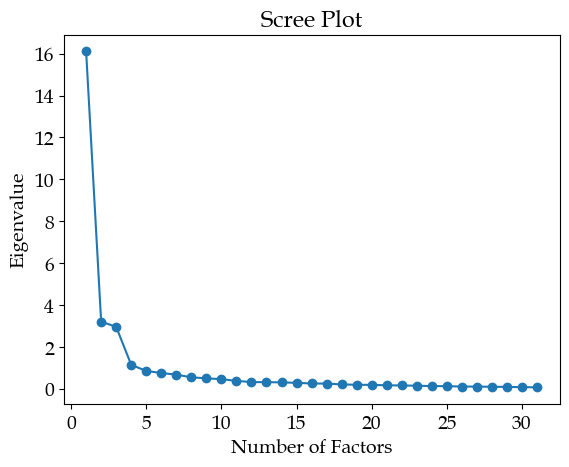

                                    0         1         2         3
BB_ToU                       0.771838  0.296257  0.120140 -0.013689
BB_AcademicReputation        0.848553  0.323567  0.115264  0.044281
BB_ProgramOffered            0.821941  0.305609  0.124196  0.066721
BB_CourseCurriculum          0.882083  0.309295  0.112846  0.073384
BB_CulturalExperience        0.831494  0.279592  0.128631 -0.026359
BB_Facilities_resources      0.872176  0.287436  0.079063  0.042209
BB_SafetyCampus              0.877379  0.308592  0.119802  0.057283
BB_DressCode                 0.628045  0.219215  0.142555 -0.094933
BB_Infrastructure            0.808514  0.340677  0.094906 -0.055782
BB_FacultyProfile            0.867313  0.294437  0.113465 -0.014659
BB_Discipline                0.802278  0.316773  0.147405  0.018156
BB_CareerOpportunities       0.878626  0.317243  0.075288  0.096310
BB_HS                        0.828779  0.323324  0.129880  0.040974
SN_Family                    0.208613  0.090004 

In [13]:
# Scree Plot for Eigenvalues
ev, _ = fa.get_eigenvalues()
plt.plot(range(1, len(ev)+1), ev, marker="o")
plt.xlabel("Number of Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

# Display factor loadings
loadings = pd.DataFrame(fa.loadings_, index=efa_data.columns)
print(loadings)

In [14]:
# Initialize and fit Factor Analyzer
fa = FactorAnalyzer(n_factors=3, rotation='varimax')  # Adjust n_factors as needed
fa.fit(efa_data)

FactorAnalyzer(rotation='varimax', rotation_kwargs={})

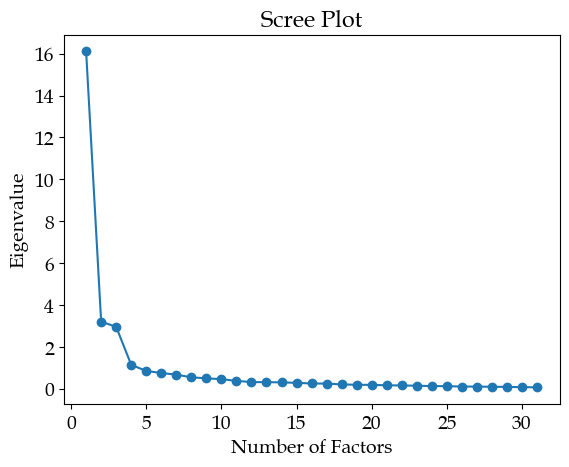

                                    0         1         2
BB_ToU                       0.766356  0.304575  0.125513
BB_AcademicReputation        0.846441  0.330605  0.120440
BB_ProgramOffered            0.821189  0.311717  0.128738
BB_CourseCurriculum          0.881729  0.315680  0.117688
BB_CulturalExperience        0.824821  0.289131  0.134954
BB_Facilities_resources      0.870548  0.294645  0.084256
BB_SafetyCampus              0.876097  0.315480  0.124831
BB_DressCode                 0.617005  0.229634  0.148421
BB_Infrastructure            0.799355  0.351131  0.101494
BB_FacultyProfile            0.861557  0.303714  0.119691
BB_Discipline                0.798298  0.324505  0.152636
BB_CareerOpportunities       0.879594  0.322847  0.079737
BB_HS                        0.826332  0.330409  0.134859
SN_Family                    0.215637  0.087056  0.593721
SN_Friends                   0.045643  0.080866  0.767523
SN_Seniors                   0.072145  0.051568  0.838571
SN_RelativesNe

In [15]:
# Scree Plot for Eigenvalues
ev, _ = fa.get_eigenvalues()
plt.plot(range(1, len(ev)+1), ev, marker="o")
plt.xlabel("Number of Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

# Display factor loadings
loadings = pd.DataFrame(fa.loadings_, index=efa_data.columns)
print(loadings)

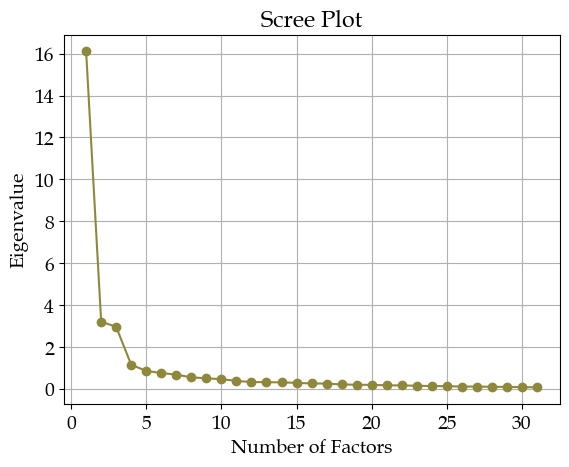

                                    0         1         2
BB_ToU                       0.766356  0.304575  0.125513
BB_AcademicReputation        0.846441  0.330605  0.120440
BB_ProgramOffered            0.821189  0.311717  0.128738
BB_CourseCurriculum          0.881729  0.315680  0.117688
BB_CulturalExperience        0.824821  0.289131  0.134954
BB_Facilities_resources      0.870548  0.294645  0.084256
BB_SafetyCampus              0.876097  0.315480  0.124831
BB_DressCode                 0.617005  0.229634  0.148421
BB_Infrastructure            0.799355  0.351131  0.101494
BB_FacultyProfile            0.861557  0.303714  0.119691
BB_Discipline                0.798298  0.324505  0.152636
BB_CareerOpportunities       0.879594  0.322847  0.079737
BB_HS                        0.826332  0.330409  0.134859
SN_Family                    0.215637  0.087056  0.593721
SN_Friends                   0.045643  0.080866  0.767523
SN_Seniors                   0.072145  0.051568  0.838571
SN_RelativesNe

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set font to Book Antiqua and size
mpl.rcParams['font.family'] = 'Book Antiqua'
mpl.rcParams['font.size'] = 14  # or 12, based on your preference

# Scree Plot for Eigenvalues
ev, _ = fa.get_eigenvalues()
plt.plot(range(1, len(ev)+1), ev, marker="o", color="#8e883d")
plt.xlabel("Number of Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

# Display factor loadings
loadings = pd.DataFrame(fa.loadings_, index=efa_data.columns)
print(loadings)


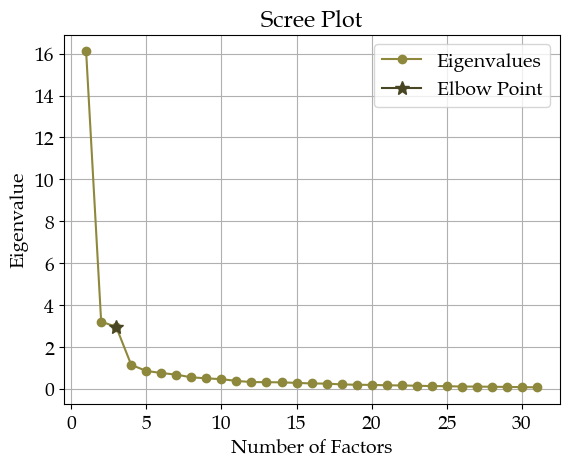

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Set font
mpl.rcParams['font.family'] = 'Book Antiqua'
mpl.rcParams['font.size'] = 14

# Scree Plot
ev, _ = fa.get_eigenvalues()
plt.plot(range(1, len(ev)+1), ev, marker="o", color="#8e883d", label='Eigenvalues')

# Highlight the elbow point (example: at index 3)
elbow_idx = 3  # Change as needed (1-based index)
plt.plot(elbow_idx, ev[elbow_idx - 1], marker='*', color='#494623', markersize=10, label='Elbow Point')

# Labels and grid
plt.xlabel("Number of Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap


# Assuming 'loadings' is already created:
# loadings = pd.DataFrame(fa.loadings_, index=efa_data.columns)

# Optional: Rename columns for clarity
loadings.columns = ['Factor 1', 'Factor 2', 'Factor 3']

# Define your custom brand color palette
brand_cmap = LinearSegmentedColormap.from_list(
    name="brand_cmap",
    colors=["#E8E7D8", "#8E883D", "#C3892B"],  # [low, mid, high]
    N=256
)


# Set figure size
plt.figure(figsize=(10, 12))

# Create the heatmap
sns.heatmap(loadings, annot=True, cmap="brand_cmap", center=0, fmt=".2f", linewidths=0.5)

# Add labels and title
plt.title("Factor Loadings Heatmap (Varimax Rotated)", fontsize=16)
plt.xlabel("Factors")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()


In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams


# Set global font to Book Antiqua
rcParams['font.family'] = 'Book Antiqua'
# Define your custom colormap
brand_cmap = LinearSegmentedColormap.from_list(
    name="brand_cmap",
    colors=["#8E883D", "#E8E7D8", "#C3892B"],  # Replace with your brand colors
    N=256
)

# Plot the heatmap using the custom colormap object
plt.figure(figsize=(10, 12))
sns.heatmap(loadings, annot=True, cmap=brand_cmap, center=0, fmt=".2f", linewidths=0.5)

plt.title("Factor Loadings Heatmap (Varimax Rotated)", fontsize=16)
plt.xlabel("Factors")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your factor loadings as a DataFrame (replace this with your actual data)
# This is based on your provided 4-factor EFA loadings
data = {
    'Factor1': [
        0.771838, 0.848553, 0.821941, 0.882083, 0.831494, 0.872176, 0.877379, 0.628045,
        0.808514, 0.867313, 0.802278, 0.878626, 0.828779, 0.208613, 0.049417, 0.081120,
        0.062505, 0.099277, 0.067363, 0.106938, 0.163370, 0.296935, 0.328674, 0.332801,
        0.428838, 0.312997, 0.366817, 0.374166, 0.375915, 0.435176, 0.199602
    ],
    'Factor2': [
        0.296257, 0.323567, 0.305609, 0.309295, 0.279592, 0.287436, 0.308592, 0.219215,
        0.340677, 0.294437, 0.316773, 0.317243, 0.323324, 0.090004, 0.080972, 0.048647,
        0.024017, 0.064048, 0.099746, 0.182978, 0.696182, 0.821881, 0.812099, 0.834816,
        0.812875, 0.819790, 0.823522, 0.805818, 0.814495, 0.807069, 0.588707
    ],
    'Factor3': [
        0.120140, 0.115264, 0.124196, 0.112846, 0.128631, 0.079063, 0.119802, 0.142555,
        0.094906, 0.113465, 0.147405, 0.075288, 0.129880, 0.605062, 0.766847, 0.835520,
        0.738469, 0.782528, 0.143367, 0.122259, 0.076679, 0.076060, 0.073707, 0.071723,
        0.068090, 0.107902, 0.076047, 0.118494, 0.102470, 0.067681, 0.094426
    ],
    'Factor4': [
        -0.013689, 0.044281, 0.066721, 0.073384, -0.026359, 0.042209, 0.057283, -0.094933,
        -0.055782, -0.014659, 0.018156, 0.096310, 0.040974, 0.196150, 0.030668, -0.050198,
        -0.095192, -0.074278, 0.050683, 0.112875, -0.399471, -0.175999, -0.162209, -0.144837,
        0.133131, 0.111537, 0.037103, 0.129953, 0.135847, 0.187710, 0.060135
    ]
}

variables = [
    "BB_ToU", "Academic reputation", "Program offered", "Course Curriculum", "Cultural experience",
    "Facilities/resources", "Safety campus (BB)", "Dress Code", "Infrastructure", "Faculty Profile",
    "Discipline", "Career Opportunities", "HS", "SN [Family]", "SN [Friends]", "SN [Seniors]",
    "SN [Relatives]", "SN [Teachers]", "SN_SameBehaviour", "Selfesteem", "Scholarship", "Guidance",
    "Language", "Accommodation", "Safety campus (PB)", "City Location", "Course Fee", "Ranking",
    "Reputation", "Course Availability", "Nearby to Home"
]

df_loadings = pd.DataFrame(data, index=variables)

# Optional: remove weak loading items if needed
# df_loadings = df_loadings.loc[~df_loadings.index.isin(['SN_SameBehaviour', 'Selfesteem'])]

# Plotting heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_loadings, annot=True, cmap="coolwarm", center=0, cbar_kws={'label': 'Loading'})
plt.title("Factor Loadings Heatmap (Varimax Rotation, 4 Factors)")
plt.ylabel("Survey Items")
plt.xlabel("Factors")
plt.tight_layout()
plt.show()


In [ ]:
from graphviz import Digraph

# Define factors
factors = ['F1_Brand', 'F2_PracticalBenefits', 'F3_SocialNorms', 'F4_Misc']

# Define items under each factor (based on high loadings from your EFA)
factor_items = {
    'F1_Brand': [
        "BB_ToU", "Academic reputation", "Program offered", "Course Curriculum",
        "Cultural experience", "Facilities/resources", "Safety campus (BB)",
        "Infrastructure", "Faculty Profile", "Discipline", "Career Opportunities", "HS"
    ],
    'F2_PracticalBenefits': [
        "Scholarship", "Guidance", "Language", "Accommodation",
        "Safety campus (PB)", "City Location", "Course Fee", "Ranking",
        "Reputation", "Course Availability", "Nearby to Home"
    ],
    'F3_SocialNorms': [
        "SN [Family]", "SN [Friends]", "SN [Seniors]", "SN [Relatives]",
        "SN [Teachers]"
    ],
    'F4_Misc': [
        "SN_SameBehaviour", "Selfesteem", "Dress Code"
    ]
}

# Create a directed graph
dot = Digraph(comment='EFA Path Diagram')
dot.attr(rankdir='LR', size='8,5')

# Add factor nodes
for factor in factors:
    dot.node(factor, shape='circle', style='filled', fillcolor='lightblue', fontsize='12')

# Add item nodes and connect them to factors
for factor, items in factor_items.items():
    for item in items:
        node_id = item.replace(" ", "_").replace("[", "").replace("]", "")
        dot.node(node_id, label=item, shape='box', style='filled', fillcolor='lightgray', fontsize='10')
        dot.edge(factor, node_id)

# Render and display
dot.render('efa_path_diagram', format='png', cleanup=True)
dot.view()


In [ ]:
from graphviz import Digraph

# Define factors and their items with loadings (simplified real names)
factor_structure = {
    "F1_Brand": [
        ("BB_ToU", 0.77),
        ("Academic reputation", 0.85),
        ("Program offered", 0.82),
        ("Course Curriculum", 0.88),
        ("Cultural experience", 0.83),
        ("Facilities/resources", 0.87),
        ("Safety campus (BB)", 0.88),
        ("Infrastructure", 0.81),
        ("Faculty Profile", 0.87),
        ("Discipline", 0.80),
        ("Career Opportunities", 0.88),
        ("HS", 0.83),
    ],
    "F2_PracticalBenefits": [
        ("Scholarship", 0.70),
        ("Guidance", 0.82),
        ("Language", 0.81),
        ("Accommodation", 0.83),
        ("Safety campus (PB)", 0.81),
        ("City Location", 0.82),
        ("Course Fee", 0.82),
        ("Ranking", 0.81),
        ("Reputation", 0.81),
        ("Course Availability", 0.81),
        ("Nearby to Home", 0.59),
    ],
    "F3_SocialNorms": [
        ("SN_Family", 0.61),
        ("SN_Friends", 0.77),
        ("SN_Seniors", 0.84),
        ("SN_Relatives", 0.74),
        ("SN_Teachers", 0.78),
    ],
    "F4_Misc": [
        ("SN_SameBehaviour", 0.99),
        ("Selfesteem", 0.18),
        ("Dress Code", 0.63),
    ],
}

# Create the path diagram
dot = Digraph(comment='EFA Path Diagram')
dot.attr(rankdir='LR', size='10,6')

# Add factor nodes
for factor in factor_structure:
    dot.node(factor, shape='ellipse', style='filled', fillcolor='lightblue', fontsize='12')

# Add item nodes and edges with loadings
for factor, items in factor_structure.items():
    for item, loading in items:
        node_id = item.replace(" ", "_").replace("(", "").replace(")", "")
        dot.node(node_id, label=item, shape='box', style='filled', fillcolor='lightgray', fontsize='10')
        dot.edge(factor, node_id, label=str(round(loading, 2)))

# Output the diagram
dot.render('efa_path_diagram_with_loadings', format='png', cleanup=True)
dot.view()


In [ ]:
cfa_data.columns

In [ ]:
model_desc = """
# Measurement model
Behavioural_Beliefs =~ BB_ToU + BB_AcademicReputation + BB_ProgramOffered + BB_CourseCurriculum + BB_CulturalExperience + BB_Facilities_resources + BB_SafetyCampus + BB_DressCode + BB_Infrastructure + BB_FacultyProfile + BB_Discipline + BB_CareerOpportunities + BB_HS
Normative_Beliefs =~ SN_Family + SN_Friends + SN_Seniors + SN_RelativesNeighbors + SN_Teachers + SN_SameBehaviour + Selfesteem
Perceived_Behavioural =~ PB_ScholarshipAvailability + PB_UniversityTeamGuidance + PB_LanguageSpoken + PB_AccomodationCostofLiving + PB_SafetyinCampus + PB_UniversitylocatedCity + PB_CourseFee + PB_Ranking + PB_ReputationBrand + PB_AvailabilityofCourse + PB_NearbytoHome 
"""

# Step 3: Create and fit the model
model = Model(model_desc)
model.fit(cfa_data)

# Step 4: Output the results
results = model.inspect()
print(results)

In [ ]:
df1.columns